In [1]:
# -------------------- IMPORT LIBRARIES --------------------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [2]:
# -------------------- DATA LOADING --------------------
df = pd.read_csv("Student_Performance.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtyp

In [3]:
# -------------------- DATA HANDLING --------------------
# Remove duplicates
df.drop_duplicates(inplace=True)

# Drop missing values
df.dropna(inplace=True)

In [4]:
# -------------------- ENCODE CATEGORICAL (if any) --------------------
# Example for Yes/No columns
for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].unique()

        if set(unique_vals) == {'Yes', 'No'}:
            df[col] = df[col].map({'Yes': 1, 'No': 0})

In [5]:
# If more categories exist:
df = pd.get_dummies(df, drop_first=True)

print("\nProcessed Data:")
print(df.head())


Processed Data:
   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [7]:
# -------------------- TARGET COLUMN --------------------
# Change this if needed
target_column = df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]
print("\nTarget Column Used:", target_column)


Target Column Used: Performance Index


In [8]:
# -------------------- TRAIN TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# -------------------- MODEL TRAINING --------------------
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# -------------------- PREDICTIONS --------------------
y_pred = model.predict(X_test)

In [11]:
# -------------------- EVALUATION --------------------
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [12]:
print("\n--- Evaluation ---")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


--- Evaluation ---
MSE : 4.305900938538476
RMSE: 2.075066490148804
R2 Score: 0.9884301209927054


In [13]:
# -------------------- COEFFICIENTS --------------------
print("\nFeature Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(col, ":", coef)


Feature Coefficients:
Hours Studied : 2.851021897391883
Previous Scores : 1.018430343479819
Extracurricular Activities : 0.5738229675498985
Sleep Hours : 0.472073293409318
Sample Question Papers Practiced : 0.18870365910309247


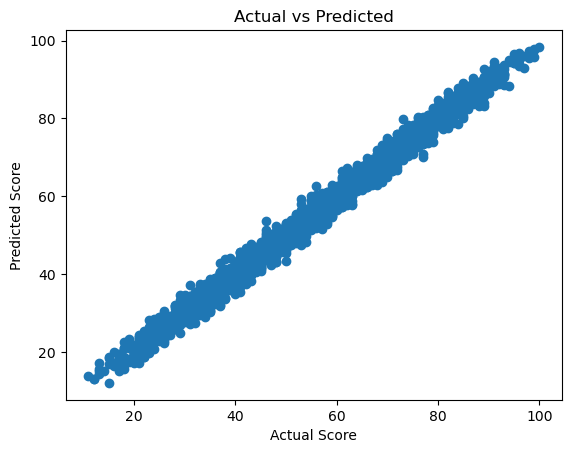

In [14]:
# -------------------- VISUALIZATION --------------------
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.show()

In [15]:
# -------------------- USER PREDICTION --------------------
print("\nEnter values for prediction:")

input_values = {}

for col in X.columns:
    val = float(input(f"{col}: "))
    input_values[col] = val

input_df = pd.DataFrame([input_values])

prediction = model.predict(input_df)

print("\nPredicted Score:", round(prediction[0], 2))


Enter values for prediction:


Hours Studied:  12
Previous Scores:  10
Extracurricular Activities:  5
Sleep Hours:  5
Sample Question Papers Practiced:  10



Predicted Score: 17.53
